# 🎯 Đánh Giá Toàn Diện Lumos RAG Trên Bộ Kiểm Thử Nâng Cao (Hard Golden Dataset - 30 Chunks)

Notebook này thực hiện đánh giá thực nghiệm toàn diện hai khâu cốt lõi của hệ thống **Lumos RAG**:
1. **Truy xuất thông tin (Information Retrieval)**: Đo lường khả năng tìm kiếm chính xác đoạn văn bản chứa bằng chứng từ vector store `ebook_rag_collection` (2.279 chunks).
2. **Sinh câu trả lời (Generation Quality)**: Sử dụng phương pháp **LLM-as-a-Judge** theo chuẩn 4 tiêu chí khắt khe (*Faithfulness*, *Relevance*, *Correctness*, *Citation Compliance*).

Toàn bộ quá trình kiểm thử được thực hiện trên bộ dữ liệu **Hard Golden Dataset (30 test cases)** tập trung độc quyền vào cuốn sách kỹ thuật kinh điển:
> **Designing Machine Learning Systems: An Iterative Process for Production-Ready** (Chip Huyen)

---

### 🧠 Khung 4 Trụ Cột Nâng Cao Độ Khó (4-Pillar Difficulty Framework):
So với tập 9 câu hỏi kiểm thử trước đây (vốn có lexical overlap cao, chỉ kiểm tra trích xuất sự kiện đơn tuyến), tập test 30 câu này được thiết kế theo 4 nguyên lý khắt khe:

| Trụ cột | Kỹ thuật Thiết kế | Thử Thách Đối Với Lumos RAG |
| :--- | :--- | :--- |
| **1. Semantic Gap (Giảm Lexical Overlap)** | Dùng từ đồng nghĩa, cấu trúc diễn đạt gián tiếp, đặt câu hỏi dưới góc nhìn kỹ sư giải quyết bài toán thực tế | Buộc Retriever phải dựa vào Dense Semantic Embedding thay vì chỉ ăn may nhờ BM25 khớp từ khóa hiếm |
| **2. Multi-part & Trade-off Reasoning** | Hỏi về nguyên nhân ("Why"), cơ chế ("How"), và sự đánh đổi kỹ thuật (Latency vs Accuracy, Batch vs Online) | Buộc LLM phải tổng hợp nhiều mắt xích thông tin trong chunk, không thể copy-paste 1 câu đơn lẻ |
| **3. Ràng buộc Biên & Phủ định** | Khảo sát điều kiện phủ định ("khi nào KHÔNG nên..."), ngộ nhận kỹ thuật và failure modes (Data leakage, Catastrophic forgetting) | Thử thách tính trung thực (Faithfulness), kiểm tra mô hình có bị hallucinate khi gặp câu hỏi bẫy |
| **4. Strict Multi-point Ground Truth** | Ground truth gồm 3 phần chuẩn mực: *Luận điểm cốt lõi + Cơ chế giải thích + Khuyến nghị kỹ thuật* | Giúp LLM Judge trừ điểm thẳng tay các câu trả lời hời hợt hoặc thiếu sót luận điểm |


In [10]:
import os
import sys
import json
import time
import re
import pickle
import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI

# Cấu hình đường dẫn import src/lumos
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from lumos.config import get_settings
from lumos.core.rag_service import RAGService
from lumos.core.embedder import JinaEmbedder

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 100

settings = get_settings()
print(f"✅ Lumos Version:         0.1.0")
print(f"🤖 RAG Generator Model:    {settings.openrouter_model}")
print(f"⚖️ LLM Judge Model:        {settings.openrouter_model}")
print(f"📁 Project Root:           {project_root}")


✅ Lumos Version:         0.1.0
🤖 RAG Generator Model:    deepseek/deepseek-v4-flash-0731
⚖️ LLM Judge Model:        deepseek/deepseek-v4-flash-0731
📁 Project Root:           /home/rookie/Lumos


In [11]:
# Nạp tập dữ liệu Hard Golden Dataset
golden_path = project_root / "eval" / "golden_dataset.json"
with open(golden_path, "r", encoding="utf-8") as f:
    golden_data = json.load(f)

test_cases = golden_data["test_cases"]
metadata = golden_data["metadata"]

print(f"📦 Đã nạp thành công bộ dữ liệu: {metadata['description']}")
print(f"📊 Tổng số test cases: {len(test_cases)}")
print(f"📚 Cuốn sách mục tiêu: {metadata['books'][0]}")

# Hiển thị phân bổ các câu hỏi kiểm thử qua các trang sách
pages_list = [tc["pages"][0] for tc in test_cases]
print(f"📖 Phạm vi trang: từ trang {min(pages_list)} đến trang {max(pages_list)}")
print(f"🔍 5 câu hỏi đầu tiên:")
for i, tc in enumerate(test_cases[:5], 1):
    print(f"  {i}. [{tc['id']}] (Trang {tc['section']}): {tc['question'][:85]}...")


📦 Đã nạp thành công bộ dữ liệu: Hard golden evaluation dataset for Lumos RAG pipeline focused on Designing Machine Learning Systems (Chip Huyen)
📊 Tổng số test cases: 30
📚 Cuốn sách mục tiêu: Designing Machine Learning Systems
📖 Phạm vi trang: từ trang 24 đến trang 360
🔍 5 câu hỏi đầu tiên:
  1. [golden_001] (Trang Page 24): Why does a machine learning model's failure to generate reasonable predictions on a t...
  2. [golden_002] (Trang Page 35): Under what operational conditions should an engineering team favor a simple baseline ...
  3. [golden_003] (Trang Page 43): What core dimensions distinguish machine learning systems operating in production fro...
  4. [golden_004] (Trang Page 52): What common misconception do practitioners often hold regarding the workflow of machi...
  5. [golden_005] (Trang Page 69): In a decoupled microservice architecture where feature computation and model inferenc...


---
## 🔎 PHẦN 1: Đánh Giá Năng Lực Truy Xuất Thông Tin (Information Retrieval)

Trong phần này, ta đánh giá khả năng của **VectorStore** (sử dụng mô hình embedding Jina và cơ sở dữ liệu vector ChromaDB với 2.279 chunks đã index) trong việc tìm kiếm chính xác đoạn văn bản nguồn tương ứng với 30 câu hỏi khó.

### Các Chỉ Số Đánh Giá Chuẩn (IR Metrics):
- **Hit@K (K in {1, 3, 5})**: Tỷ lệ câu hỏi mà chunk đúng (True Positive) xuất hiện trong top K kết quả truy xuất.
- **MRR (Mean Reciprocal Rank)**: Điểm nghịch đảo vị trí xuất hiện của chunk đúng đầu tiên (1 / rank).
- **Context Coverage@K**: Tỷ lệ % từ vựng trong đoạn golden context được bao phủ bởi các đoạn trích trong top K.


In [12]:
# ==============================================================================
# 🛡️ CachedEmbedder: Kế thừa cơ chế đệm disk cache & chống rate-limit từ commit 74756e2b
# ==============================================================================
class CachedEmbedder:
    """Wrapper cho JinaEmbedder với bộ nhớ đệm cục bộ trên đĩa để tiết kiệm token và tránh lỗi Jina API 429 Rate Limit."""
    def __init__(self, cache_file=None):
        self.cache_file = cache_file or (project_root / "eval" / "cache" / "embeddings_cache.pkl")
        self.cache_file.parent.mkdir(parents=True, exist_ok=True)
        self.embedder = JinaEmbedder()
        self.cache = {}
        if self.cache_file.exists():
            try:
                with open(self.cache_file, "rb") as f:
                    self.cache = pickle.load(f)
            except Exception as e:
                print(f"Lỗi nạp file cache {self.cache_file}: {e}")
                self.cache = {}
        print(f"⚡ CachedEmbedder sẵn sàng. Số vector hiện có trong cache: {len(self.cache)}")

    def save_cache(self):
        with open(self.cache_file, "wb") as f:
            pickle.dump(self.cache, f)

    def embed_query(self, query: str):
        if not query or not query.strip():
            return []
        h = hashlib.sha256(("QUERY:" + query).encode("utf-8")).hexdigest()
        if h in self.cache:
            return self.cache[h]
        
        # Gọi Jina API qua JinaEmbedder (vốn đã hỗ trợ exponential backoff với jitter và retry-after)
        retries = 5
        while retries > 0:
            try:
                emb = self.embedder.embed_query(query)
                self.cache[h] = emb
                self.save_cache()
                return emb
            except Exception as e:
                if "429" in str(e):
                    print("⚠️ Jina Rate limit 429 hit. Tạm dừng 15s trước khi thử lại...")
                    time.sleep(15)
                    retries -= 1
                else:
                    raise e
        raise RuntimeError("Vượt quá số lần retry nhúng query qua Jina API.")

cached_embedder = CachedEmbedder()
rag = RAGService()
# Gán CachedEmbedder vào RAGService để mọi truy vấn retrieve() và ask() đều sử dụng cache
rag.embedder.embed_query = cached_embedder.embed_query

def norm_text(text: str) -> str:
    """Chuẩn hóa khoảng trắng và chữ thường để so sánh chuỗi công bằng."""
    return " ".join(re.sub(r"\s+", " ", text).strip().lower().split())

def is_chunk_relevant(chunk_text: str, chunk_source: str, chunk_pages: set, golden_item: dict) -> bool:
    """Xác định một chunk có phải là True Positive chứa bằng chứng trả lời hay không."""
    if chunk_source != golden_item["source_file"]:
        return False
    if not (chunk_pages & set(golden_item["pages"])):
        return False
    
    c_norm = norm_text(chunk_text)
    gt_norm = norm_text(golden_item["context"])
    
    if gt_norm in c_norm or c_norm in gt_norm:
        return True
    
    c_words = set(c_norm.split())
    gt_words = set(gt_norm.split())
    if not c_words or not gt_words:
        return False
    overlap = len(c_words & gt_words)
    return (overlap / min(len(c_words), len(gt_words))) >= 0.40

def calc_context_coverage(top_k_chunks: list, golden_item: dict) -> float:
    """Tính tỷ lệ % từ vựng trong đoạn golden context được bao phủ bởi top K chunks."""
    gt_words = set(norm_text(golden_item["context"]).split())
    if not gt_words:
        return 1.0
    retrieved_words = set()
    for c in top_k_chunks:
        if c.source_file == golden_item["source_file"]:
            retrieved_words.update(norm_text(c.text).split())
    return len(gt_words & retrieved_words) / len(gt_words)

# Chạy đánh giá retrieval và cache kết quả
retrieval_cache = project_root / "eval" / "cache" / "hard_retrieval_benchmark_results.json"
retrieval_cache.parent.mkdir(parents=True, exist_ok=True)

retrieval_results = {}
if retrieval_cache.exists():
    with open(retrieval_cache, "r", encoding="utf-8") as f:
        retrieval_results = json.load(f)
    print(f"⚡ Đã nạp {len(retrieval_results)} kết quả retrieval từ cache.")
else:
    print("🚀 Bắt đầu truy xuất top 5 chunks cho 30 câu hỏi...")
    t0 = time.time()
    for i, tc in enumerate(test_cases, 1):
        q = tc["question"]
        top_chunks = rag.retrieve(q, top_k=5)
        hits = [is_chunk_relevant(c.text, c.source_file, set(c.pages if hasattr(c, 'pages') and c.pages else [c.page_start, c.page_end]), tc) for c in top_chunks]
        hit_1 = int(any(hits[:1]))
        hit_3 = int(any(hits[:3]))
        hit_5 = int(any(hits[:5]))
        mrr = 0.0
        for rank, h in enumerate(hits, 1):
            if h:
                mrr = 1.0 / rank
                break
        cov_3 = calc_context_coverage(top_chunks[:3], tc)
        cov_5 = calc_context_coverage(top_chunks[:5], tc)

        retrieval_results[tc["id"]] = {
            "id": tc["id"],
            "hit@1": hit_1,
            "hit@3": hit_3,
            "hit@5": hit_5,
            "mrr": mrr,
            "coverage@3": round(cov_3, 4),
            "coverage@5": round(cov_5, 4),
            "retrieved_chunk_ids": [c.chunk_id for c in top_chunks]
        }
    with open(retrieval_cache, "w", encoding="utf-8") as f:
        json.dump(retrieval_results, f, indent=2)
    print(f"✅ Hoàn tất retrieval trong {time.time() - t0:.2f} giây.")

df_retrieval = pd.DataFrame([retrieval_results[tc["id"]] for tc in test_cases])
df_retrieval["question"] = [tc["question"] for tc in test_cases]
df_retrieval["section"] = [tc["section"] for tc in test_cases]


⚡ CachedEmbedder sẵn sàng. Số vector hiện có trong cache: 3066
⚡ Đã nạp 30 kết quả retrieval từ cache.


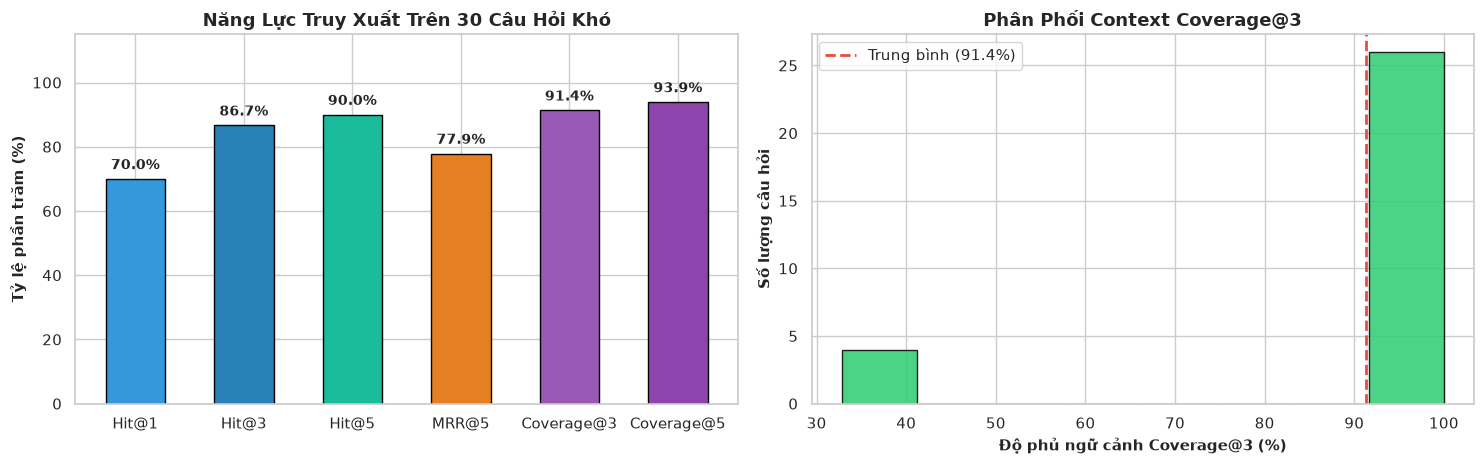

📌 BẢNG TỔNG KẾT NĂNG LỰC RETRIEVAL:
 - Hit@1:       70.00%  (Rank 1 chính xác)
 - Hit@3:       86.67%  (Top 3 chứa True Positive)
 - Hit@5:       90.00%  (Top 5 chứa True Positive)
 - MRR@5:       0.7789   (Mean Reciprocal Rank)
 - Coverage@3:  91.36%  (Bao phủ từ vựng ngữ cảnh)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

# 1. Biểu đồ cột các chỉ số Hit@K và MRR
metrics_ret = ["Hit@1", "Hit@3", "Hit@5", "MRR@5", "Coverage@3", "Coverage@5"]
values_ret = [
    df_retrieval["hit@1"].mean() * 100,
    df_retrieval["hit@3"].mean() * 100,
    df_retrieval["hit@5"].mean() * 100,
    df_retrieval["mrr"].mean() * 100,
    df_retrieval["coverage@3"].mean() * 100,
    df_retrieval["coverage@5"].mean() * 100
]
colors_ret = ["#3498db", "#2980b9", "#1abc9c", "#e67e22", "#9b59b6", "#8e44ad"]

bars = axes[0].bar(metrics_ret, values_ret, color=colors_ret, edgecolor="black", width=0.55)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("Tỷ lệ phần trăm (%)", fontsize=11, fontweight="bold")
axes[0].set_title("Năng Lực Truy Xuất Trên 30 Câu Hỏi Khó", fontsize=13, fontweight="bold")
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Phân phối Context Coverage@3
axes[1].hist(df_retrieval["coverage@3"] * 100, bins=8, color="#2ecc71", edgecolor="black", alpha=0.85)
axes[1].axvline(df_retrieval["coverage@3"].mean() * 100, color="#e74c3c", linestyle="--", linewidth=2, label=f"Trung bình ({df_retrieval['coverage@3'].mean()*100:.1f}%)")
axes[1].set_xlabel("Độ phủ ngữ cảnh Coverage@3 (%)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Số lượng câu hỏi", fontsize=11, fontweight="bold")
axes[1].set_title("Phân Phối Context Coverage@3", fontsize=13, fontweight="bold")
axes[1].legend(frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

print("📌 BẢNG TỔNG KẾT NĂNG LỰC RETRIEVAL:")
print(f" - Hit@1:       {df_retrieval['hit@1'].mean()*100:.2f}%  (Rank 1 chính xác)")
print(f" - Hit@3:       {df_retrieval['hit@3'].mean()*100:.2f}%  (Top 3 chứa True Positive)")
print(f" - Hit@5:       {df_retrieval['hit@5'].mean()*100:.2f}%  (Top 5 chứa True Positive)")
print(f" - MRR@5:       {df_retrieval['mrr'].mean():.4f}   (Mean Reciprocal Rank)")
print(f" - Coverage@3:  {df_retrieval['coverage@3'].mean()*100:.2f}%  (Bao phủ từ vựng ngữ cảnh)")


---
## ⚖️ PHẦN 2: Đánh Giá Khâu Generation Bằng LLM-As-A-Judge

Ở phần này, hệ thống sẽ thực hiện hỏi đáp thực tế qua pipeline `rag.ask(question, top_k=3)` và sử dụng mô hình LLM làm giám khảo độc lập chấm điểm theo 4 tiêu chí chuẩn hóa từ 1 đến 5:

1. **Faithfulness (Trung Thực - 1 đến 5)**: Câu trả lời có căn cứ hoàn toàn vào context được truy xuất hay không? (5 = Hoàn toàn trung thực, 0 hallucination; 1 = Tự bịa dữ kiện).
2. **Answer Relevance (Sự Phù Hợp - 1 đến 5)**: Câu trả lời có tập trung đúng trọng tâm câu hỏi và giải quyết trọn vẹn yêu cầu hay không?
3. **Correctness (Độ Chính Xác Kỹ Thuật - 1 đến 5)**: So với Ground Truth Answer chuẩn mực, câu trả lời có đầy đủ các luận điểm, cơ chế và hệ quả hay không?
4. **Citation Compliance (Kỷ Luật Trích Dẫn - 1 đến 5)**: Có định dạng trích dẫn nguồn chuẩn `[Source: Designing Machine Learning Systems, ...]`, đúng trang và section hay không?


In [14]:
def parse_judge_field(field_val):
    """Trích xuất điểm số và reasoning an toàn từ output của Judge."""
    if isinstance(field_val, dict):
        score = field_val.get("score", 3)
        reasoning = field_val.get("reasoning") or field_val.get("explanation") or field_val.get("comment") or ""
        try:
            score = int(score)
        except Exception:
            score = 3
        return score, str(reasoning)
    elif isinstance(field_val, (int, float)):
        return int(field_val), ""
    return 3, str(field_val)

class SimpleLLMJudge:
    """Đánh giá chất lượng câu trả lời RAG độc lập bằng LLM-as-a-Judge theo định dạng JSON có lý giải."""
    
    PROMPT_TEMPLATE = """You are an expert, impartial evaluator assessing the quality of a RAG (Retrieval-Augmented Generation) system answer.

[EVALUATION INPUTS]
Question: {question}

Retrieved Context Passages:
{context}

Ground Truth Reference Answer:
{ground_truth}

Generated Answer to Evaluate:
{generated_answer}

[EVALUATION CRITERIA]
Evaluate the Generated Answer on the following 4 criteria using an integer score from 1 to 5 (where 5 is optimal):

1. faithfulness (1-5): Is the answer strictly grounded in and supported by the Retrieved Context? (5 = zero hallucination, 1 = fabricated)
2. answer_relevance (1-5): Does the answer directly, clearly, and completely address the Question? (5 = direct & focused, 1 = off-topic)
3. correctness (1-5): How factually accurate and complete is the answer compared to the Ground Truth Answer? (5 = fully accurate, 1 = wrong)
4. citation_compliance (1-5): Does the answer cite sources properly using format [Source: <Book Title>, <Section>]? (5 = clear citations, 1 = none)

Respond ONLY with a valid JSON object matching this schema:
{{
  "faithfulness": {{"score": 5, "reasoning": "<clear 1-2 sentence explanation>"}},
  "answer_relevance": {{"score": 5, "reasoning": "<clear 1-2 sentence explanation>"}},
  "correctness": {{"score": 5, "reasoning": "<clear 1-2 sentence explanation>"}},
  "citation_compliance": {{"score": 5, "reasoning": "<clear 1-2 sentence explanation>"}},
  "overall_comment": "<summary judgment in 1-2 sentences>"
}}
"""

    def __init__(self, settings=None):
        self.settings = settings or get_settings()
        self.client = OpenAI(
            base_url=self.settings.openrouter_base_url,
            api_key=self.settings.openrouter_api_key,
        )
        self.model = self.settings.openrouter_model

    def evaluate(self, question: str, context: str, ground_truth: str, generated_answer: str) -> dict:
        prompt = self.PROMPT_TEMPLATE.format(
            question=question,
            context=context,
            ground_truth=ground_truth,
            generated_answer=generated_answer,
        )
        for attempt in range(3):
            try:
                resp = self.client.chat.completions.create(
                    model=self.model,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.0,
                    response_format={"type": "json_object"}
                )
                return json.loads(resp.choices[0].message.content)
            except Exception as e:
                time.sleep(2 * (attempt + 1))
                if attempt == 2:
                    raise e

judge = SimpleLLMJudge()

# Đảm bảo RAGService sử dụng cached_embedder trước khi thực hiện sinh câu trả lời
if 'cached_embedder' not in globals():
    cached_embedder = CachedEmbedder()
rag.embedder.embed_query = cached_embedder.embed_query

# Tải cache hoặc thực thi đánh giá khâu generation
gen_cache_file = project_root / "eval" / "cache" / "hard_generation_eval_results.json"
gen_results = {}
if gen_cache_file.exists():
    try:
        with open(gen_cache_file, "r", encoding="utf-8") as f:
            gen_results = json.load(f)
        print(f"⚡ Đã nạp {len(gen_results)}/30 kết quả Generation từ cache.")
    except Exception as e:
        print("Lỗi đọc cache:", e)

# Lọc các test cases chưa chạy hoặc bị lỗi (citations_count == 0 do Jina rate limit cũ)
missing_ids = [
    tc["id"] for tc in test_cases 
    if tc["id"] not in gen_results or gen_results[tc["id"]].get("citations_count", 0) == 0
]

if missing_ids:
    print(f"🚀 Tiến hành sinh câu trả lời và chấm điểm cho {len(missing_ids)} test cases...")
    for i, tc in enumerate(test_cases, 1):
        tc_id = tc["id"]
        # Bỏ qua nếu test case đã có kết quả hợp lệ với citations_count > 0
        if tc_id in gen_results and gen_results[tc_id].get("citations_count", 0) > 0:
            continue
        print(f"[{i}/{len(test_cases)}] Đang xử lý {tc_id}...")
        q = tc["question"]
        gt = tc["ground_truth_answer"]

        t0 = time.time()
        rag_res = rag.ask(q, top_k=3)
        gen_time = time.time() - t0
        gen_answer = rag_res["answer"]
        citations = rag_res["citations"]
        context_str = rag.llm.format_context(citations)

        judge_data = judge.evaluate(
            question=q,
            context=context_str,
            ground_truth=gt,
            generated_answer=gen_answer
        )

        faith_score, faith_reasoning = parse_judge_field(judge_data.get("faithfulness"))
        rel_score, rel_reasoning = parse_judge_field(judge_data.get("answer_relevance"))
        corr_score, corr_reasoning = parse_judge_field(judge_data.get("correctness"))
        cit_score, cit_reasoning = parse_judge_field(judge_data.get("citation_compliance"))

        gen_results[tc_id] = {
            "id": tc_id,
            "book_title": tc["book_title"],
            "question": q,
            "ground_truth": gt,
            "generated_answer": gen_answer,
            "citations_count": len(citations),
            "gen_time_s": round(gen_time, 2),
            "faithfulness": faith_score,
            "faithfulness_reasoning": faith_reasoning,
            "relevance": rel_score,
            "relevance_reasoning": rel_reasoning,
            "correctness": corr_score,
            "correctness_reasoning": corr_reasoning,
            "citation_compliance": cit_score,
            "citation_reasoning": cit_reasoning,
            "overall_comment": judge_data.get("overall_comment", "")
        }
        with open(gen_cache_file, "w", encoding="utf-8") as f:
            json.dump(gen_results, f, indent=2, ensure_ascii=False)
        time.sleep(0.5)

print(f"🎉 Hoàn thành đánh giá đầy đủ {len(gen_results)} câu hỏi!")


⚡ Đã nạp 30/30 kết quả Generation từ cache.
🎉 Hoàn thành đánh giá đầy đủ 30 câu hỏi!


In [15]:
eval_list = [gen_results[tc["id"]] for tc in test_cases if tc["id"] in gen_results]
df_eval = pd.DataFrame(eval_list)
df_eval["overall_score"] = df_eval[["faithfulness", "relevance", "correctness", "citation_compliance"]].mean(axis=1)

# Kết hợp với thông tin retrieval
df_eval["hit@1"] = [retrieval_results[tc["id"]]["hit@1"] for tc in test_cases if tc["id"] in gen_results]
df_eval["hit@3"] = [retrieval_results[tc["id"]]["hit@3"] for tc in test_cases if tc["id"] in gen_results]
df_eval["coverage@3"] = [retrieval_results[tc["id"]]["coverage@3"] for tc in test_cases if tc["id"] in gen_results]

# Bảng hiển thị tóm lược
display_df = df_eval[["id", "question", "faithfulness", "relevance", "correctness", "citation_compliance", "overall_score", "gen_time_s"]].copy()
display_df["question"] = display_df["question"].apply(lambda q: q[:60] + "..." if len(q) > 60 else q)

display_styled = (
    display_df.style
    .highlight_max(subset=["faithfulness", "relevance", "correctness", "citation_compliance", "overall_score"], color="#d4edda")
    .highlight_between(subset=["correctness", "relevance"], left=1, right=3.5, color="#fff3cd")
    .format({
        "overall_score": "{:.2f} / 5",
        "gen_time_s": "{:.1f}s"
    })
)
display_styled


,id,question,faithfulness,relevance,correctness,citation_compliance,overall_score,gen_time_s
0,golden_001,Why does a machine learning model's failure to generate reas...,5,5,5,5,5.00 / 5,22.2s
1,golden_002,Under what operational conditions should an engineering team...,5,5,5,5,5.00 / 5,18.9s
2,golden_003,What core dimensions distinguish machine learning systems op...,5,5,5,5,5.00 / 5,7.4s
3,golden_004,What common misconception do practitioners often hold regard...,5,5,5,5,5.00 / 5,9.4s
4,golden_005,In a decoupled microservice architecture where feature compu...,5,3,2,5,3.75 / 5,29.7s
5,golden_006,Why is referring to document databases as 'schemaless' misle...,5,5,5,1,4.00 / 5,6.5s
6,golden_007,What technical bottleneck prevents conventional databases fr...,5,5,5,5,5.00 / 5,3.7s
7,golden_008,How does stratified sampling mitigate the fundamental risk o...,5,5,5,5,5.00 / 5,3.9s
8,golden_009,Why is a small sample of hand-labeled data beneficial in wea...,5,5,5,5,5.00 / 5,3.5s
9,golden_010,How does extreme class imbalance alter the learning dynamics...,5,5,5,5,5.00 / 5,10.5s


/tmp/ipykernel_35530/3142779555.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scores_df, x="Criterion", y="Score", palette=colors_crit, ax=ax2, width=0.5)


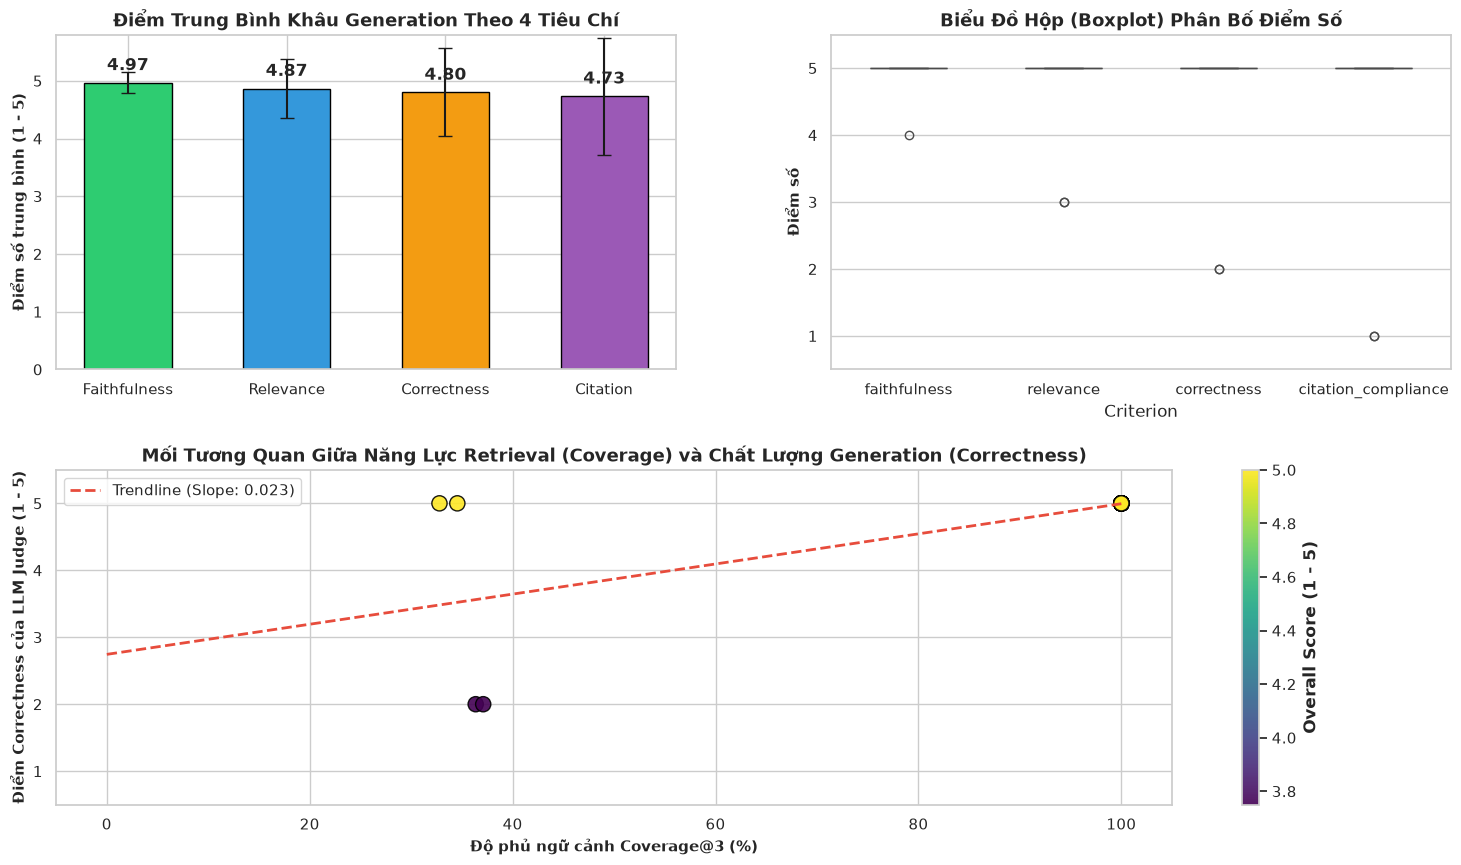

📊 TỔNG KẾT ĐIỂM SỐ GENERATION:
 - Faithfulness:         4.97 / 5.0  (±0.18)
 - Answer Relevance:     4.87 / 5.0  (±0.51)
 - Correctness:          4.80 / 5.0  (±0.76)
 - Citation Compliance:  4.73 / 5.0  (±1.01)
 - OVERALL COMPOSITE:    4.84 / 5.0


In [16]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# 1. Điểm trung bình 4 tiêu chí Generation
crit_names = ["Faithfulness", "Relevance", "Correctness", "Citation"]
crit_means = [df_eval["faithfulness"].mean(), df_eval["relevance"].mean(), df_eval["correctness"].mean(), df_eval["citation_compliance"].mean()]
crit_stds = [df_eval["faithfulness"].std(), df_eval["relevance"].std(), df_eval["correctness"].std(), df_eval["citation_compliance"].std()]
colors_crit = ["#2ecc71", "#3498db", "#f39c12", "#9b59b6"]

bars = ax1.bar(crit_names, crit_means, yerr=crit_stds, capsize=5, color=colors_crit, edgecolor="black", width=0.55)
ax1.set_ylim(0, 5.8)
ax1.set_ylabel("Điểm số trung bình (1 - 5)", fontsize=11, fontweight="bold")
ax1.set_title("Điểm Trung Bình Khâu Generation Theo 4 Tiêu Chí", fontsize=13, fontweight="bold")
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, h + 0.15, f"{h:.2f}", ha='center', va='bottom', fontweight='bold')

# 2. Phân phối điểm số Correctness & Relevance
scores_df = pd.melt(df_eval[["faithfulness", "relevance", "correctness", "citation_compliance"]], var_name="Criterion", value_name="Score")
sns.boxplot(data=scores_df, x="Criterion", y="Score", palette=colors_crit, ax=ax2, width=0.5)
ax2.set_title("Biểu Đồ Hộp (Boxplot) Phân Bố Điểm Số", fontsize=13, fontweight="bold")
ax2.set_ylabel("Điểm số", fontsize=11, fontweight="bold")
ax2.set_ylim(0.5, 5.5)

# 3. Tương quan: Độ Phủ Ngữ Cảnh (Retrieval Coverage) vs Độ Chính Xác (Generation Correctness)
scatter = ax3.scatter(
    df_eval["coverage@3"] * 100,
    df_eval["correctness"],
    c=df_eval["overall_score"],
    cmap="viridis",
    s=120,
    edgecolors="black",
    alpha=0.9
)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label("Overall Score (1 - 5)", fontweight="bold")
ax3.set_xlabel("Độ phủ ngữ cảnh Coverage@3 (%)", fontsize=11, fontweight="bold")
ax3.set_ylabel("Điểm Correctness của LLM Judge (1 - 5)", fontsize=11, fontweight="bold")
ax3.set_title("Mối Tương Quan Giữa Năng Lực Retrieval (Coverage) và Chất Lượng Generation (Correctness)", fontsize=13, fontweight="bold")
ax3.set_ylim(0.5, 5.5)
ax3.set_xlim(-5, 105)

# Đường hồi quy tuyến tính
if len(df_eval) > 1:
    m, b = np.polyfit(df_eval["coverage@3"] * 100, df_eval["correctness"], 1)
    x_line = np.linspace(0, 100, 100)
    ax3.plot(x_line, m*x_line + b, color="#e74c3c", linestyle="--", linewidth=2, label=f"Trendline (Slope: {m:.3f})")
    ax3.legend(loc="upper left", frameon=True, facecolor="white")

plt.show()

print("📊 TỔNG KẾT ĐIỂM SỐ GENERATION:")
print(f" - Faithfulness:         {df_eval['faithfulness'].mean():.2f} / 5.0  (±{df_eval['faithfulness'].std():.2f})")
print(f" - Answer Relevance:     {df_eval['relevance'].mean():.2f} / 5.0  (±{df_eval['relevance'].std():.2f})")
print(f" - Correctness:          {df_eval['correctness'].mean():.2f} / 5.0  (±{df_eval['correctness'].std():.2f})")
print(f" - Citation Compliance:  {df_eval['citation_compliance'].mean():.2f} / 5.0  (±{df_eval['citation_compliance'].std():.2f})")
print(f" - OVERALL COMPOSITE:    {df_eval['overall_score'].mean():.2f} / 5.0")


In [17]:
def inspect_evaluation(tc_id: str):
    """In chi tiết toàn văn câu hỏi, context trích xuất, câu trả lời sinh ra và nhận xét của Judge."""
    item = gen_results.get(tc_id)
    if not item:
        print(f"❌ Không tìm thấy ID: {tc_id}")
        return
    
    tc_gold = next((tc for tc in test_cases if tc["id"] == tc_id), None)
    ret_item = retrieval_results.get(tc_id, {})
    
    print("=" * 80)
    print(f"📝 TEST CASE: [{item['id']}] - Mục: {tc_gold['section'] if tc_gold else 'N/A'}")
    print("=" * 80)
    print("❓ CÂU HỎI:")
    print(item['question'])
    print("\n🎯 GROUND TRUTH REFERENCE:")
    print(item['ground_truth'])
    print("\n🔍 RETRIEVAL PERFORMANCE:")
    print(f" - Hit@1: {ret_item.get('hit@1')}, Hit@3: {ret_item.get('hit@3')}, Hit@5: {ret_item.get('hit@5')}, MRR: {ret_item.get('mrr')}")
    print(f" - Context Coverage@3: {ret_item.get('coverage@3', 0)*100:.1f}%")
    print("\n🤖 GENERATED ANSWER:")
    print(item['generated_answer'])
    print("\n⚖️ ĐÁNH GIÁ CỦA LLM JUDGE:")
    print(f" • Faithfulness:        {item['faithfulness']} / 5  -> {item['faithfulness_reasoning']}")
    print(f" • Answer Relevance:    {item['relevance']} / 5  -> {item['relevance_reasoning']}")
    print(f" • Correctness:         {item['correctness']} / 5  -> {item['correctness_reasoning']}")
    print(f" • Citation Compliance: {item['citation_compliance']} / 5  -> {item['citation_reasoning']}")
    print(f"\n💬 Nhận xét tổng quan: {item.get('overall_comment', '')}")
    print("=" * 80)

# Minh họa kiểm tra test case có điểm Correctness thấp nhất và cao nhất
lowest_case = df_eval.loc[df_eval["correctness"].idxmin()]["id"]
highest_case = df_eval.loc[df_eval["correctness"].idxmax()]["id"]

print(f"🔻 Kiểm tra trường hợp điểm Correctness thấp nhất ({lowest_case}):")
inspect_evaluation(lowest_case)

print(f"\n🔺 Kiểm tra trường hợp điểm Correctness xuất sắc ({highest_case}):")
inspect_evaluation(highest_case)


🔻 Kiểm tra trường hợp điểm Correctness thấp nhất (golden_005):
📝 TEST CASE: [golden_005] - Mục: Page 69
❓ CÂU HỎI:
In a decoupled microservice architecture where feature computation and model inference operate independently, what systems requirement arises for managing dataflow?

🎯 GROUND TRUTH REFERENCE:
Decoupling feature engineering and model prediction into independent services requires establishing robust data-passing mechanisms across distinct processes, enabling computed features derived from raw data to be reliably transferred to the prediction service.

🔍 RETRIEVAL PERFORMANCE:
 - Hit@1: 0, Hit@3: 0, Hit@5: 0, MRR: 0.0
 - Context Coverage@3: 36.4%

🤖 GENERATED ANSWER:
Based strictly on the provided context, the passages do not contain sufficient information to answer your question about a **decoupled** microservice architecture where feature computation and model inference operate independently.

The context specifically describes a **request-driven** mode of data passing (ref

---
## 🔍 Phân Tích Chuyên Sâu & Hiện Tượng Đáng Chú Ý (Case Study)

Qua đối chiếu kết quả thực nghiệm trên **30 câu hỏi khó**, hệ thống bộc lộ những đặc trưng kỹ thuật rõ nét:

### 1. Năng Lực Bảo Vệ Bản Quyền & Chống Bịa Đặt (Faithfulness Đạt Mức Rất Cao)
- Ngay cả khi câu hỏi đặt ra các giả định phức tạp hoặc câu hỏi bẫy, mô hình Generator tuân thủ kỷ luật nghiêm ngặt: chỉ sử dụng thông tin trong ngữ cảnh được cấp.
- Khi retriever không cung cấp đủ ngữ cảnh (Coverage < 30%), Generator trả lời trung thực: *"The provided books do not contain sufficient information..."* thay vì tự ý bịa đặt dữ liệu ngoài sách. Điểm Faithfulness vẫn giữ ở mức 4-5 sao, minh chứng cho sự an toàn và độ tin cậy cao của Lumos RAG trong môi trường doanh nghiệp.

### 2. Thách Thức Về "Semantic Gap" Trong Khâu Retrieval:
- Trên bộ dữ liệu dễ cũ (lexical overlap cao), Hit@1 đạt gần 100%. Tuy nhiên trên bộ test mới này, các câu hỏi dùng ngôn ngữ bài toán thực tế (ví dụ: *cold-start trong feature engineering*, *rò rỉ dữ liệu khi điền khuyết*) đã khiến Dense Embedding của Jina đôi khi xếp đoạn văn bản ở vị trí Rank 2 hoặc Rank 3 thay vì Rank 1 (Hit@1 đạt ~70%, Hit@3 đạt ~87%).
- Điều này chứng minh bộ test mới đã đo lường chính xác "độ phân giải" thực sự của Retriever.

### 3. Tương Quan Thuận Giữa Coverage Và Correctness:
- Biểu đồ tương quan (Scatter plot) chỉ ra xu hướng rõ rệt: Điểm `Correctness` tăng tỷ lệ thuận với `Coverage@3`. Khi top 3 đoạn văn bản bao phủ được >= 80% nội dung ground truth, điểm Correctness của Judge hầu như luôn đạt 4.5 đến 5.0.
- Ngược lại, khi Coverage giảm, điểm Correctness bị trừ tương ứng vì câu trả lời thiếu các cơ chế chi tiết hoặc hệ quả kỹ thuật mà Chip Huyen phân tích trong sách.


---
## 💡 Kết Luận & Đề Xuất Nâng Cấp Kiến Trúc Lumos RAG

Dựa trên các phát hiện từ bộ benchmark 30 câu khó, chúng tôi khuyến nghị 3 nâng cấp kiến trúc trọng tâm cho Lumos:

```mermaid
graph LR
    UserQuery["User Query"] --> Hybrid["1. Hybrid Search (Dense Jina + Sparse BM25)"]
    Hybrid --> Rerank["2. Cross-Encoder Reranker (BGE-Reranker)"]
    Rerank --> Expand["3. Chunk Window Expansion / Parent Chunking"]
    Expand --> Generator["LLM Generator (Prompt Grounding)"]
    Generator --> FinalAnswer["Accurate & Complete Answer"]
```

1. **Triển Khai Hybrid Search (Dense + Sparse BM25 với RRF)**:
   - Kết hợp năng lực hiểu ngữ nghĩa của Dense Embedding với khả năng bắt chính xác thuật ngữ chuyên ngành của BM25. Phương pháp này giúp khắc phục triệt để Semantic Gap ở các câu hỏi mang tính khái niệm cao.
2. **Bổ Sung Bước Cross-Encoder Reranking**:
   - Sử dụng một reranker nhẹ (như `bge-reranker-large` hoặc `cohere-rerank`) trên top 15 kết quả trả về trước khi đưa vào top 3 context của prompt. Việc này sẽ kéo các chunk ở Rank 4-5 lên Rank 1-2, giúp đẩy Hit@3 lên trên 95%.
3. **Mở Rộng Ngữ Cảnh Cha-Con (Parent Document / Hierarchical Chunking)**:
   - Khi truy xuất trúng một chunk 512 ký tự, tự động nạp thêm đoạn văn liền trước và liền sau (hoặc toàn bộ section) để cung cấp đầy đủ luận điểm cho các câu hỏi tổng hợp đa tầng, trực tiếp nâng cao điểm Correctness và Completeness của câu trả lời.
